In [100]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns;
import pandas as pd

In [101]:
mel_data = (
    pd.read_excel('Melbourne01.xlsx')
    .rename(columns=lambda col: col.strip())
    .dropna()
)
mel_data.head()

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C)
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0,0.969609,14.1,15.916676,23.9
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0,0.908985,13.2,14.980401,23.6
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0,0.915025,13.2,15.069879,23.7
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0,0.923560,13.4,15.201624,23.6
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0,0.927209,13.4,15.264860,23.4


In [102]:
invalid_float_count = mel_data["Wind Direction"].apply(lambda x: isinstance(x, float)).sum()
invalid_float_count

47

In [103]:
mel_data["Wind Direction"].count()

504580

In [104]:
numeric_cols = mel_data.columns.drop("Wind Direction")

mel_data[numeric_cols] = mel_data[numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)

mel_data = mel_data.dropna(subset=numeric_cols)

mel_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504500 entries, 0 to 505354
Data columns (total 18 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Year                                  504500 non-null  int64  
 1   Month                                 504500 non-null  int64  
 2   Day                                   504500 non-null  float64
 3   Hour                                  504500 non-null  float64
 4   Min                                   504500 non-null  float64
 5   Air Temp (degrees C)                  504500 non-null  float64
 6   Apparent Temp (degrees C)             504500 non-null  float64
 7   Dew Pt Temp (degrees C)               504500 non-null  float64
 8   Humidity (%)                          504500 non-null  float64
 9   Wind Direction                        504500 non-null  object 
 10  Wind Speed (km/h)                     504500 non-null  int64  
 11  Wind 

In [105]:
mel_data.rename(columns={'Min': 'Minute'}, inplace=True)

mel_data['Datetime'] = pd.to_datetime(
    mel_data[['Year','Month','Day','Hour','Minute']]
)
mel_data.sort_values('Datetime', inplace=True)
mel_data.Datetime.head()

0   2011-01-01 00:04:00
1   2011-01-01 00:14:00
2   2011-01-01 00:24:00
3   2011-01-01 00:34:00
4   2011-01-01 00:44:00
Name: Datetime, dtype: datetime64[ns]

In [106]:
temp_cols = ['Air Temp (degrees C)', 'Apparent Temp (degrees C)', 'Calculated Apparent Temp (degrees C)']
for col in temp_cols:
    mel_data = mel_data[(mel_data[col] >= -20) & (mel_data[col] <= 55)]

dew_cols = ['Dew Pt Temp (degrees C)', 'Calculated Dew Pt Temp (degrees C)']
for col in dew_cols:
    mel_data = mel_data[mel_data[col] >= -20]
    mel_data = mel_data[mel_data[col] <= mel_data['Air Temp (degrees C)']]

mel_data = mel_data[(mel_data['Humidity (%)'] >= 0) & (mel_data['Humidity (%)'] <= 100)]

mel_data = mel_data[mel_data['Wind Speed (km/h)'] >= 0]
mel_data = mel_data[(mel_data['Wind Gust  (km/h)'] >= 0) & (mel_data['Wind Gust  (km/h)'] <= 120)]

mel_data = mel_data[(mel_data['MSLP (hPa)'] >= 950) & (mel_data['MSLP (hPa)'] <= 1050)]

mel_data = mel_data[(mel_data['E (hPa)'] >= 5) & (mel_data['E (hPa)'] <= 30)]

mel_data = mel_data[(mel_data['gamma'] >= 0.5) & (mel_data['gamma'] <= 2.5)]

mel_data = mel_data[mel_data['Rainfall since 9 am (mm)'] >= 0]

mel_data["Rain"] = (mel_data["Rainfall since 9 am (mm)"] > 0).astype(int)

In [107]:
mel_data['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM'], dtype=object)

In [108]:
dummies=pd.get_dummies(mel_data['Wind Direction'], prefix='WindDir')
mel_data = mel_data.join(dummies).drop(columns=['Wind Direction'])

In [109]:
mel_data

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,11,...,False,False,False,True,False,False,False,False,False,False
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,11,...,False,False,False,True,False,False,False,False,False,False
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,9,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,2022,3,8.0,15.0,40.0,18.6,16.0,13.2,71.0,39,...,False,False,False,False,False,True,False,False,False,False
505351,2022,3,8.0,15.0,50.0,18.7,18.5,13.6,72.0,35,...,False,False,False,False,False,True,False,False,False,False
505352,2022,3,8.0,16.0,0.0,18.9,17.6,13.7,72.0,35,...,False,False,False,False,False,True,False,False,False,False
505353,2022,3,8.0,16.0,10.0,19.2,18.3,13.8,71.0,32,...,False,False,True,False,False,False,False,False,False,False


In [123]:
wind_cols = [c for c in mel_data.columns if c.startswith('WindDir_')]

daily_data = mel_data.resample('D', on='Datetime').agg({
    **{col: 'mean' for col in wind_cols},
    'Air Temp (degrees C)': 'mean',
    'Humidity (%)': 'mean',
    'MSLP (hPa)': 'mean',
    'Wind Speed (km/h)': 'mean',
    'Wind Gust  (km/h)': 'max',
    'E (hPa)': 'mean',
    'Dew Pt Temp (degrees C)': 'mean',
    'Apparent Temp (degrees C)': 'mean',
    'Rainfall since 9 am (mm)': 'last' 
})
daily_data

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,WindDir_WSW,Air Temp (degrees C),Humidity (%),MSLP (hPa),Wind Speed (km/h),Wind Gust (km/h),E (hPa),Dew Pt Temp (degrees C),Apparent Temp (degrees C),Rainfall since 9 am (mm)
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.00,0.000,0.038760,0.015504,0.007752,0.015504,0.007752,0.000000,0.023256,0.418605,...,0.038760,19.651938,61.635659,1011.784496,14.325581,43.0,13.980619,12.004651,0.000000,0.0
2011-01-02,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.563380,...,0.000000,18.560563,53.718310,1015.983099,22.704225,39.0,11.300188,8.839437,0.000000,0.0
2011-01-03,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,17.300000,51.000000,1016.400000,26.000000,35.0,10.048411,7.100000,0.000000,0.0
2011-01-04,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008696,0.000000,0.278261,...,0.026087,17.183478,59.608696,1012.045217,15.782609,37.0,11.574564,9.133043,0.000000,0.0
2011-01-05,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,0.093023,18.110853,66.565891,1010.086047,19.837209,37.0,13.699222,11.719380,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016000,0.272000,0.024000,0.048000,0.064000,0.072000,0.056000,...,0.000000,24.486400,66.512000,1009.955200,15.688000,46.0,19.023386,16.672800,25.424800,3.8
2022-03-05,0.00,0.000,0.015038,0.000000,0.007519,0.022556,0.000000,0.000000,0.007519,0.195489,...,0.210526,19.320301,89.759398,1007.534586,19.406015,43.0,20.054762,17.533835,20.012030,1.2
2022-03-06,0.00,0.000,0.000000,0.000000,0.007692,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,18.484615,79.061538,1015.901538,27.607692,57.0,16.734805,14.642308,17.083077,0.0


In [124]:
monthly_data = daily_data.resample('ME').agg({
    **{col: 'mean' for col in wind_cols},
    'Air Temp (degrees C)': 'mean',
    'Humidity (%)': 'mean',
    'MSLP (hPa)': 'mean',
    'Wind Speed (km/h)': 'mean',
    'Wind Gust  (km/h)': 'max',
    'E (hPa)': 'mean',
    'Dew Pt Temp (degrees C)': 'mean',
    'Apparent Temp (degrees C)': 'mean',
    'Rainfall since 9 am (mm)': 'sum'
})
monthly_data

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,WindDir_WSW,Air Temp (degrees C),Humidity (%),MSLP (hPa),Wind Speed (km/h),Wind Gust (km/h),E (hPa),Dew Pt Temp (degrees C),Apparent Temp (degrees C),Rainfall since 9 am (mm)
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-31,0.000000,0.022463,0.023172,0.009322,0.140998,0.016591,0.043517,0.024194,0.018791,0.235349,...,0.056277,21.383717,64.273742,1011.019754,17.388625,63.0,16.228164,13.860628,0.000000,70.0
2011-02-28,0.000000,0.013716,0.009449,0.017362,0.155332,0.008993,0.024959,0.034228,0.026912,0.239365,...,0.059485,20.338329,67.497606,1015.100713,16.230956,65.0,16.066926,13.774471,0.000000,26.4
2011-03-31,0.000000,0.003859,0.008059,0.003449,0.215612,0.011700,0.035895,0.031832,0.017804,0.185231,...,0.094440,18.871436,64.196624,1016.062099,17.506529,72.0,13.842852,11.544299,0.000000,19.4
2011-04-30,0.000000,0.002073,0.004980,0.004977,0.292986,0.009591,0.039481,0.063280,0.054531,0.085544,...,0.078324,16.232237,68.332569,1021.697434,16.906111,56.0,12.249378,9.962302,0.000000,41.8
2011-05-31,0.000000,0.001023,0.001227,0.003342,0.220691,0.000741,0.009830,0.022473,0.046816,0.089208,...,0.102182,12.905345,75.858756,1019.685407,15.381709,67.0,11.191131,8.614511,0.000000,47.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-11-30,0.013125,0.004912,0.005556,0.001904,0.117818,0.021249,0.100411,0.008501,0.012100,0.192725,...,0.038029,16.020198,71.354710,1014.446553,18.713643,82.0,12.674827,10.270571,14.267099,75.4
2021-12-31,0.016184,0.003251,0.003447,0.010280,0.118636,0.013331,0.065670,0.016328,0.022329,0.247106,...,0.049178,18.554099,63.525284,1014.609918,19.465154,80.0,13.108352,10.870994,16.788094,24.6
2022-01-31,0.022063,0.012067,0.015343,0.015359,0.104999,0.033397,0.101146,0.017677,0.028201,0.202627,...,0.039592,22.921675,64.419631,1012.404269,17.607537,65.0,17.443536,15.164986,22.964226,65.0


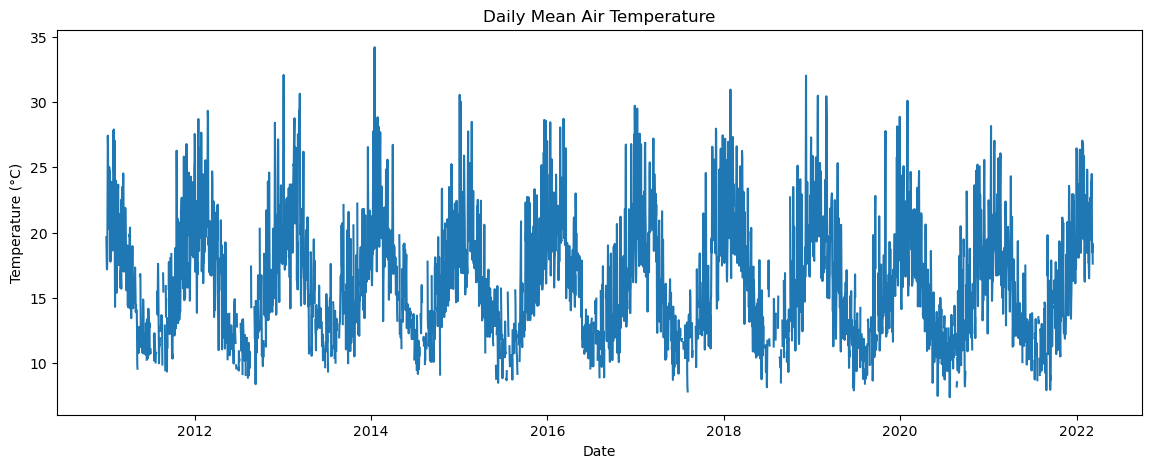

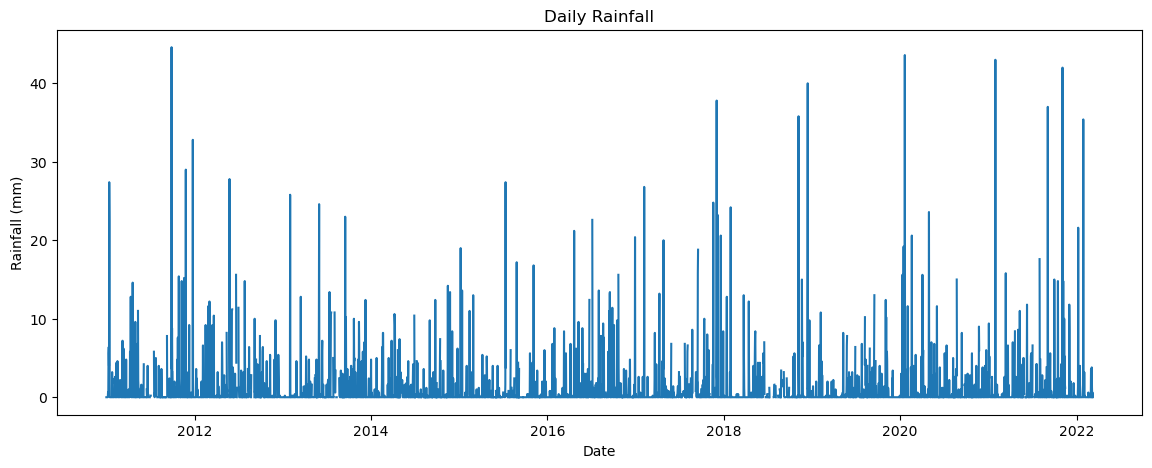

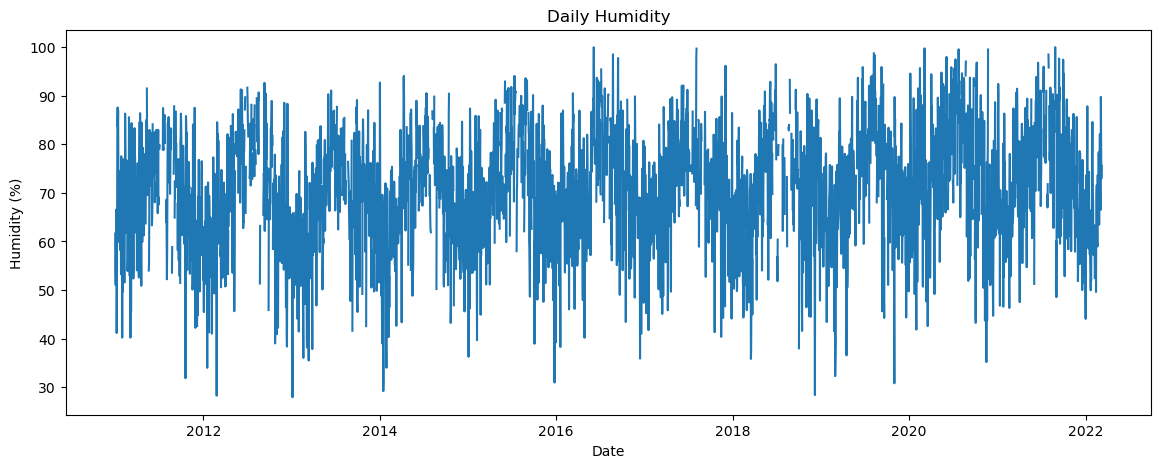

In [125]:
plt.figure(figsize=(14,5))
plt.plot(daily_data['Air Temp (degrees C)'])
plt.title('Daily Mean Air Temperature')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.show()

plt.figure(figsize=(14,5))
plt.plot(daily_data['Rainfall since 9 am (mm)'])
plt.title('Daily Rainfall')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Date')
plt.show()

plt.figure(figsize=(14,5))
plt.plot(daily_data['Humidity (%)'])
plt.title('Daily Humidity')
plt.ylabel('Humidity (%)')
plt.xlabel('Date')
plt.show()

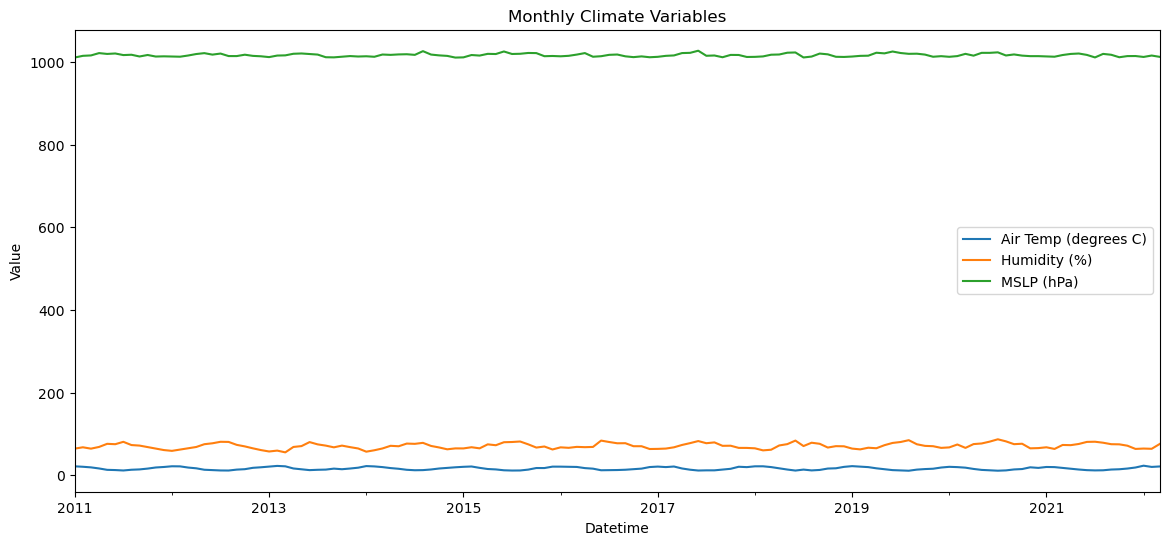

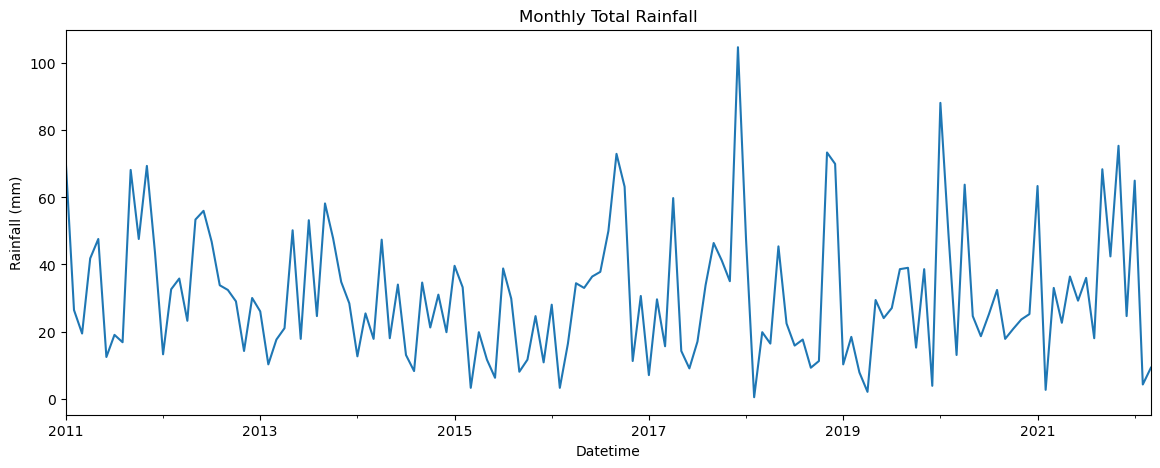

In [126]:
monthly_data[['Air Temp (degrees C)', 'Humidity (%)', 'MSLP (hPa)']].plot(
    figsize=(14,6), title='Monthly Climate Variables'
)
plt.ylabel('Value')
plt.show()

monthly_data['Rainfall since 9 am (mm)'].plot(
    figsize=(14,5), title='Monthly Total Rainfall'
)
plt.ylabel('Rainfall (mm)')
plt.show()

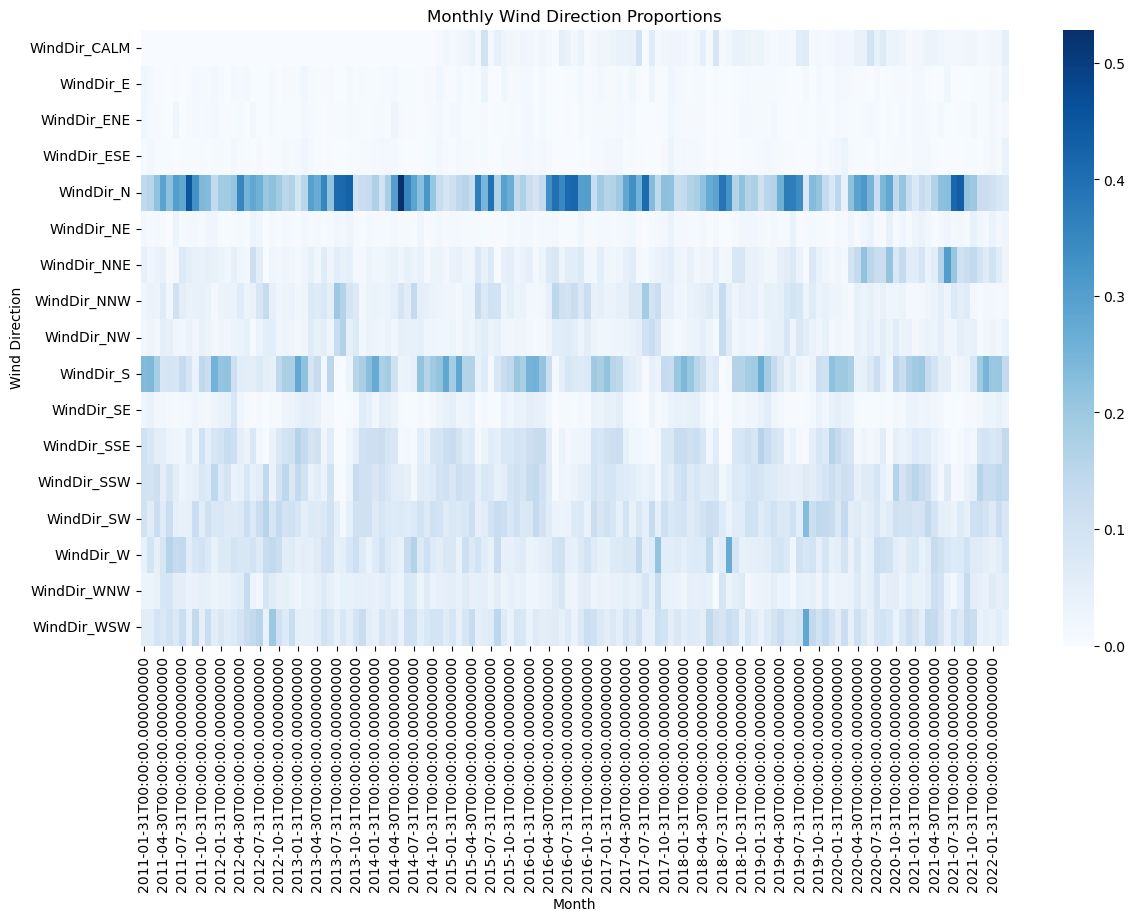

In [127]:
wind_cols = [c for c in monthly_data.columns if c.startswith('WindDir_')]

plt.figure(figsize=(14,8))
sns.heatmap(monthly_data[wind_cols].T, cmap='Blues')
plt.title('Monthly Wind Direction Proportions')
plt.xlabel('Month')
plt.ylabel('Wind Direction')
plt.show()

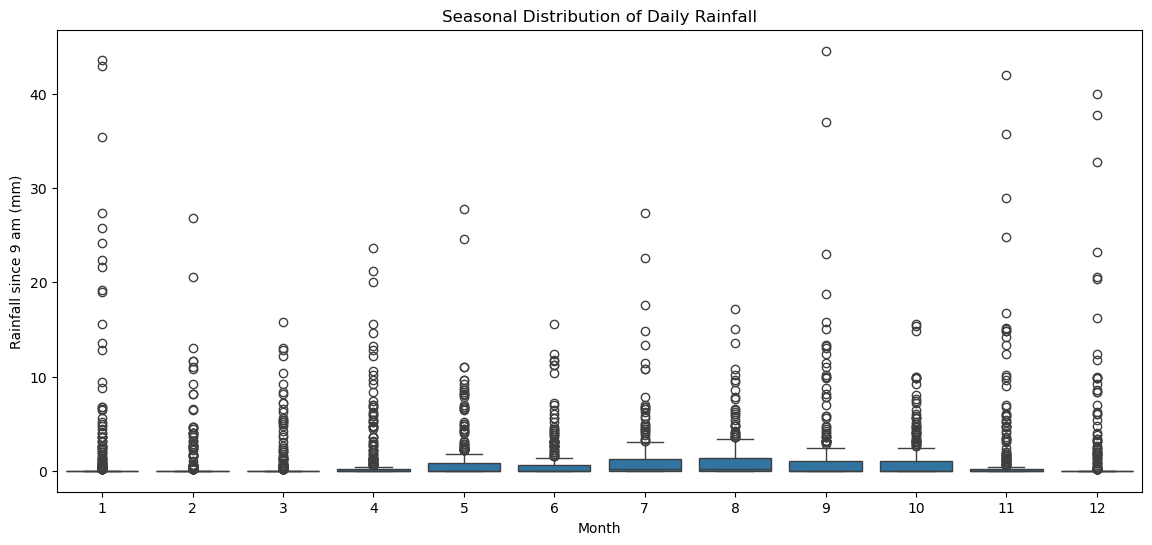

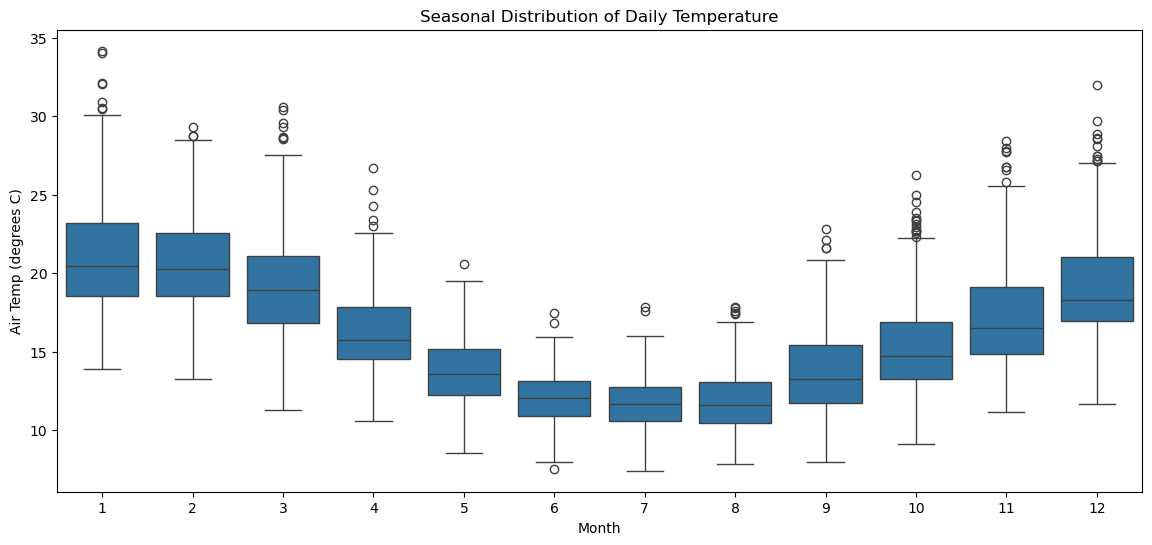

In [128]:
daily_data['Month'] = daily_data.index.month

plt.figure(figsize=(14,6))
sns.boxplot(data=daily_data, x='Month', y='Rainfall since 9 am (mm)')
plt.title('Seasonal Distribution of Daily Rainfall')
plt.show()

plt.figure(figsize=(14,6))
sns.boxplot(data=daily_data, x='Month', y='Air Temp (degrees C)')
plt.title('Seasonal Distribution of Daily Temperature')
plt.show()

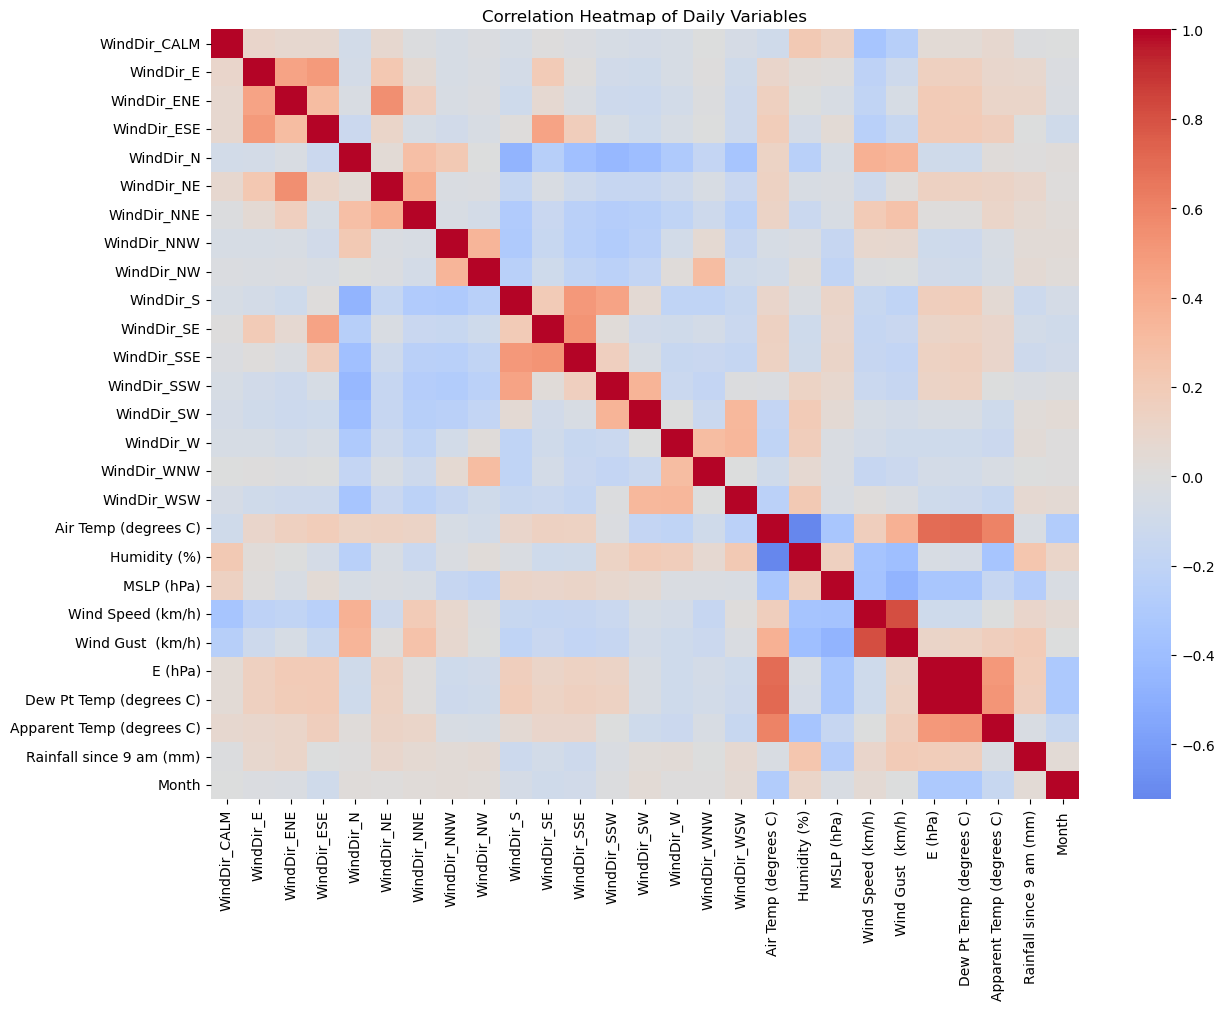

In [129]:
plt.figure(figsize=(14,10))
sns.heatmap(daily_data.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Daily Variables')
plt.show()

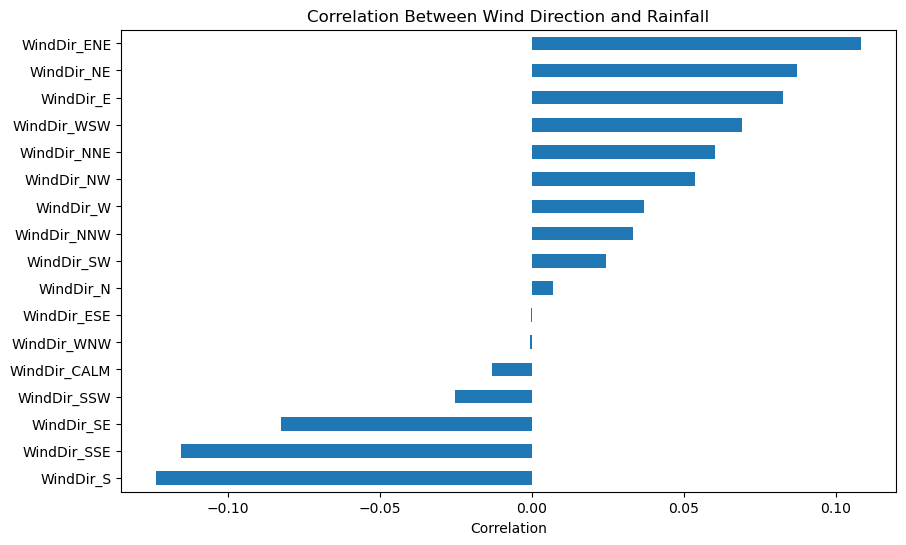

In [130]:
wind_cols = [c for c in daily_data.columns if c.startswith('WindDir_')]

corrs = daily_data[wind_cols + ['Rainfall since 9 am (mm)']].corr()['Rainfall since 9 am (mm)']

plt.figure(figsize=(10,6))
corrs[:-1].sort_values().plot(kind='barh')
plt.title('Correlation Between Wind Direction and Rainfall')
plt.xlabel('Correlation')
plt.show()

In [138]:
daily_data['RainTomorrow'] = (daily_data['Rainfall since 9 am (mm)'].shift(-1) > 0)
daily_data = daily_data.dropna(subset=['RainTomorrow'])

In [139]:
daily_data

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,Humidity (%),MSLP (hPa),Wind Speed (km/h),Wind Gust (km/h),E (hPa),Dew Pt Temp (degrees C),Apparent Temp (degrees C),Rainfall since 9 am (mm),Month,RainTomorrow
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.00,0.000,0.038760,0.015504,0.007752,0.015504,0.007752,0.000000,0.023256,0.418605,...,61.635659,1011.784496,14.325581,43.0,13.980619,12.004651,0.000000,0.0,1,False
2011-01-02,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.563380,...,53.718310,1015.983099,22.704225,39.0,11.300188,8.839437,0.000000,0.0,1,False
2011-01-03,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,51.000000,1016.400000,26.000000,35.0,10.048411,7.100000,0.000000,0.0,1,False
2011-01-04,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008696,0.000000,0.278261,...,59.608696,1012.045217,15.782609,37.0,11.574564,9.133043,0.000000,0.0,1,False
2011-01-05,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,66.565891,1010.086047,19.837209,37.0,13.699222,11.719380,0.000000,0.0,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016000,0.272000,0.024000,0.048000,0.064000,0.072000,0.056000,...,66.512000,1009.955200,15.688000,46.0,19.023386,16.672800,25.424800,3.8,3,True
2022-03-05,0.00,0.000,0.015038,0.000000,0.007519,0.022556,0.000000,0.000000,0.007519,0.195489,...,89.759398,1007.534586,19.406015,43.0,20.054762,17.533835,20.012030,1.2,3,False
2022-03-06,0.00,0.000,0.000000,0.000000,0.007692,0.000000,0.000000,0.000000,0.000000,0.000000,...,79.061538,1015.901538,27.607692,57.0,16.734805,14.642308,17.083077,0.0,3,True


In [160]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

train = daily_data.loc[:'2020-12-31']
test  = daily_data.loc['2021-01-01':]

X_train = train.drop(columns=['RainTomorrow'])
y_train = train['RainTomorrow']

X_test = test.drop(columns=['RainTomorrow'])
y_test = test['RainTomorrow']

In [161]:
rf_1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

rf_1.fit(X_train, y_train)

y_pred_1 = rf_1.predict(X_test)
y_prob_1 = rf_1.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_1))
print("Precision:", precision_score(y_test, y_pred_1))
print("Recall:", recall_score(y_test, y_pred_1))
print("F1:", f1_score(y_test, y_pred_1))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_1))
print("PR-AUC:", average_precision_score(y_test, y_prob_1))

Accuracy: 0.7083333333333334
Precision: 0.5434782608695652
Recall: 0.19230769230769232
F1: 0.2840909090909091
ROC-AUC: 0.7034004075394803
PR-AUC: 0.47216338710803607


In [162]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

rf_2 = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_2,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print(grid.best_params_)

y_pred_2 = best_rf.predict(X_test)
y_prob_2 = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_2))
print("Precision:", precision_score(y_test, y_pred_2))
print("Recall:", recall_score(y_test, y_pred_2))
print("F1:", f1_score(y_test, y_pred_2))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_2))
print("PR-AUC:", average_precision_score(y_test, y_prob_2))

{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Accuracy: 0.7337962962962963
Precision: 0.5547445255474452
Recall: 0.5846153846153846
F1: 0.5692883895131086
ROC-AUC: 0.7508660213958228
PR-AUC: 0.5510754435591045
